In [1]:
from backend.utils.gmsh_function import *
from backend.src.radiation_algorithm.radiation_algorithm import *
from backend.utils.file_path import *
from backend.utils.frequency_sweep import *

In [2]:
name = "strip"
path = setup_save_file_paths(name)

In [3]:
mm = 1e-3
width = 20  * mm
length = 2000 * mm

# feed_point = np.array([0, 0, 0])

feed_point = np.array(([0, 0, 0], [0, 0.5, 0], [0, -0.75, 0]))

In [4]:
light_speed = 3e8

frequency = 75e6
wavelength = light_speed / frequency
print(f"wavelength = {wavelength} Meter")

freq_start = 45e6
freq_stop  = 120e6

wavelength = 4.0 Meter


In [5]:
initial_mesh_size = 0.05
# initial_mesh_size = wavelength / 30
print(f"initial_mesh_size = {initial_mesh_size}")

gmsh.initialize()
model_name  = "strip_antenna"

print(f"Longueur: {width} m, Hauteur: {length} m")

# Model creation
gmsh.model.add(model_name)
setup_performance_config()

strip_antenna = gmsh.model.occ.addRectangle(-width / 2, -length / 2, 0, width, length)

# synchronize after embedding
gmsh.model.occ.synchronize()

generate_and_save_mesh(path.geo, path.msh, initial_mesh_size)

# gmsh.fltk.run()

gmsh.finalize()

initial_mesh_size = 0.05
Longueur: 0.02 m, Hauteur: 2.0 m
[PERFORMANCE] Gmsh configured to utilize 16 threads.
Geometry file saved in data/gmsh_files/strip.brep successfully
--- Starting Mesh Optimization (Dim: 2) ---
--- Optimization Complete ---
Mesh file saved in data/gmsh_files/strip.msh successfully


_ = radiation_algorithm(path, frequency, feed_point, excitation_unit_vector='y', gap_width=1.1*initial_mesh_size, voltage_amplitude=-1)

In [6]:
frequency_sweep(path, freq_start, freq_stop, feed_point, excitation_unit_vector="y", gap_width=1.1*initial_mesh_size, step=0.3e6, show=False)

MULTIPLE PORT FREQUENCY SWEEP CONFIGURATION
Number of Ports detected: 3
  > Port 0 Location: [0. 0. 0.]
  > Port 1 Location: [0.  0.5 0. ]
  > Port 2 Location: [ 0.   -0.75  0.  ]
Range: 45.00 MHz to 120.00 MHz (251 points)

Step 1/251 |   45.00 MHz | P0: -0.29dB | P1: -0.23dB | P2: -0.15dB
Step 2/251 |   45.30 MHz | P0: -0.30dB | P1: -0.24dB | P2: -0.15dB
Step 3/251 |   45.60 MHz | P0: -0.31dB | P1: -0.25dB | P2: -0.16dB
Step 4/251 |   45.90 MHz | P0: -0.33dB | P1: -0.26dB | P2: -0.17dB
Step 5/251 |   46.20 MHz | P0: -0.34dB | P1: -0.27dB | P2: -0.17dB
Step 6/251 |   46.50 MHz | P0: -0.36dB | P1: -0.29dB | P2: -0.18dB
Step 7/251 |   46.80 MHz | P0: -0.37dB | P1: -0.30dB | P2: -0.19dB
Step 8/251 |   47.10 MHz | P0: -0.39dB | P1: -0.31dB | P2: -0.20dB
Step 9/251 |   47.40 MHz | P0: -0.41dB | P1: -0.32dB | P2: -0.21dB
Step 10/251 |   47.70 MHz | P0: -0.42dB | P1: -0.34dB | P2: -0.22dB
Step 11/251 |   48.00 MHz | P0: -0.44dB | P1: -0.35dB | P2: -0.23dB
Step 12/251 |   48.30 MHz | P0: -0.4

Interpolation Applied


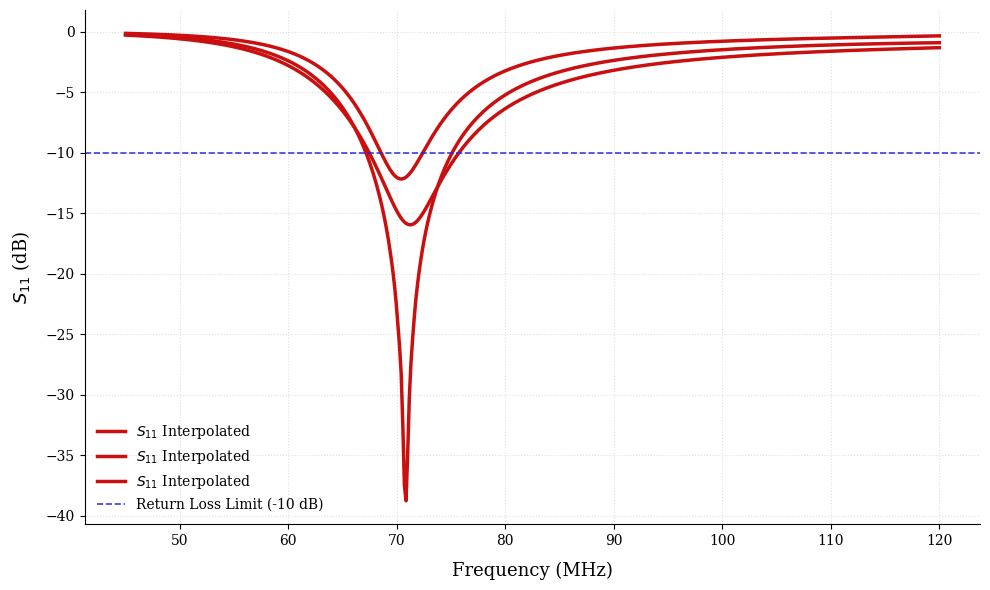

In [7]:
plot_s11(path)

Plotting all 3 ports. Note: To view a specific port, use 'port_idx=n'.


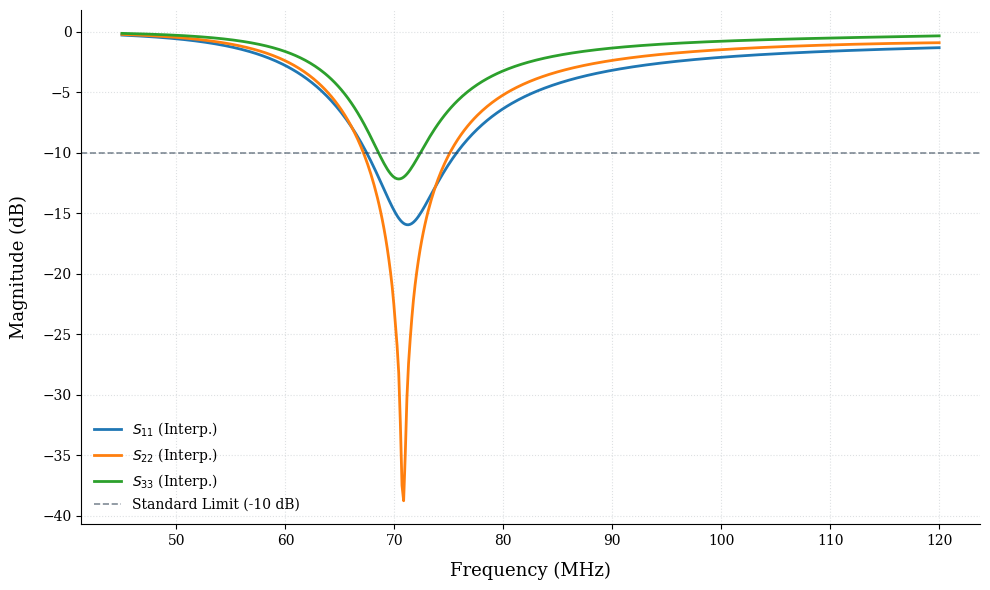

In [ ]:
plot_s_parameters(path)

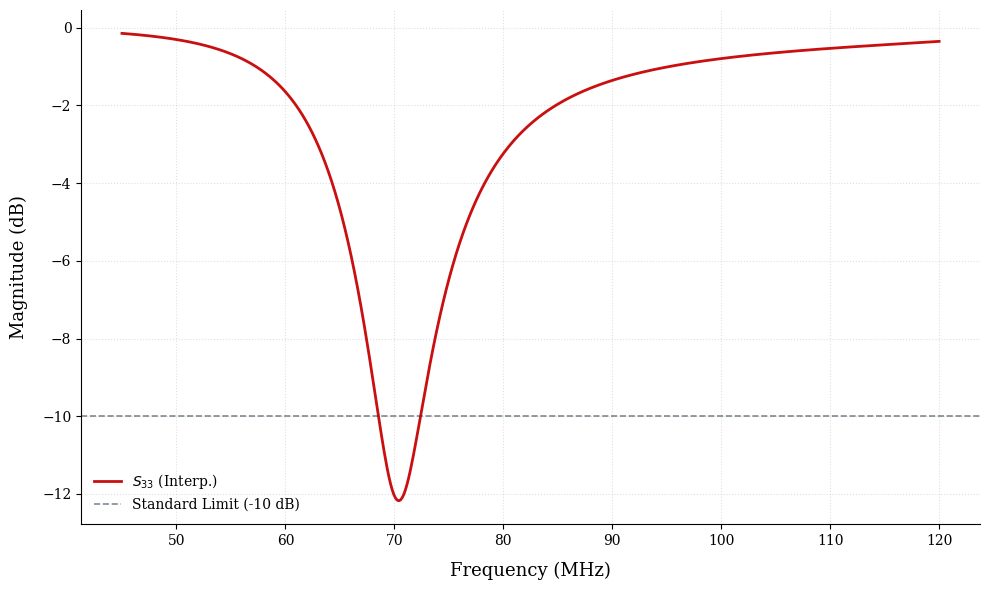

In [13]:
n = 2
plot_s_parameters(path, port_idx=n)